# QuantWeather-BD: Quantum ML for Next-Day Weather Prediction in Bangladesh

This notebook builds a hybrid Quantum Machine Learning (QML) pipeline using the NASA POWER daily weather dataset and a PennyLane + PyTorch Variational Quantum Circuit (VQC).

In [1]:
# (Optional) Install dependencies if needed
!pip install pennylane torch pandas numpy matplotlib seaborn scikit-learn joblib

Defaulting to user installation because normal site-packages is not writeable


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install tqdm

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
import torch.optim as optim

import pennylane as qml
import joblib

plt.style.use('seaborn-v0_8')
np.random.seed(42)
torch.manual_seed(42)

print('Libraries imported successfully.')

Libraries imported successfully.


## Step 1: Data Loading & Cleaning

In [4]:
# Dataset path
dataset_path = r"D:\Quantum-Enhanced Weather Forecasting for Bangladesh\Dataset\bangladesh_weather_1981_2026.csv"

# Load CSV skipping 14 header rows (not 16)
df = pd.read_csv(dataset_path, skiprows=14)

# Strip column names
df.columns = df.columns.str.strip()

# Create a single DATE column from YEAR, MO, DY
df['DATE'] = pd.to_datetime(dict(year=df['YEAR'], month=df['MO'], day=df['DY']))

# Replace -999 with NaN
df.replace(-999, np.nan, inplace=True)

# Basic checks
print(f"Dataset shape: {df.shape}")
print('\nMissing values per column:')
print(df.isna().sum())
print('\nHead of dataset:')
print(df.head())

Dataset shape: (16570, 10)

Missing values per column:
YEAR           0
MO             0
DY             0
T2M            4
T2M_MAX        4
T2M_MIN        4
RH2M           4
PRECTOTCORR    4
WS2M           4
DATE           0
dtype: int64

Head of dataset:
   YEAR  MO  DY    T2M  T2M_MAX  T2M_MIN   RH2M  PRECTOTCORR  WS2M       DATE
0  1981   1   1  18.63    26.32    12.24  55.22         0.00  1.49 1981-01-01
1  1981   1   2  19.06    25.86    13.72  51.12         0.00  0.93 1981-01-02
2  1981   1   3  19.22    25.98    13.49  55.75         0.00  0.90 1981-01-03
3  1981   1   4  19.11    26.09    13.64  53.51         0.00  1.34 1981-01-04
4  1981   1   5  19.87    26.82    13.46  58.67         0.03  1.07 1981-01-05


## Step 2: Exploratory Data Analysis (EDA)

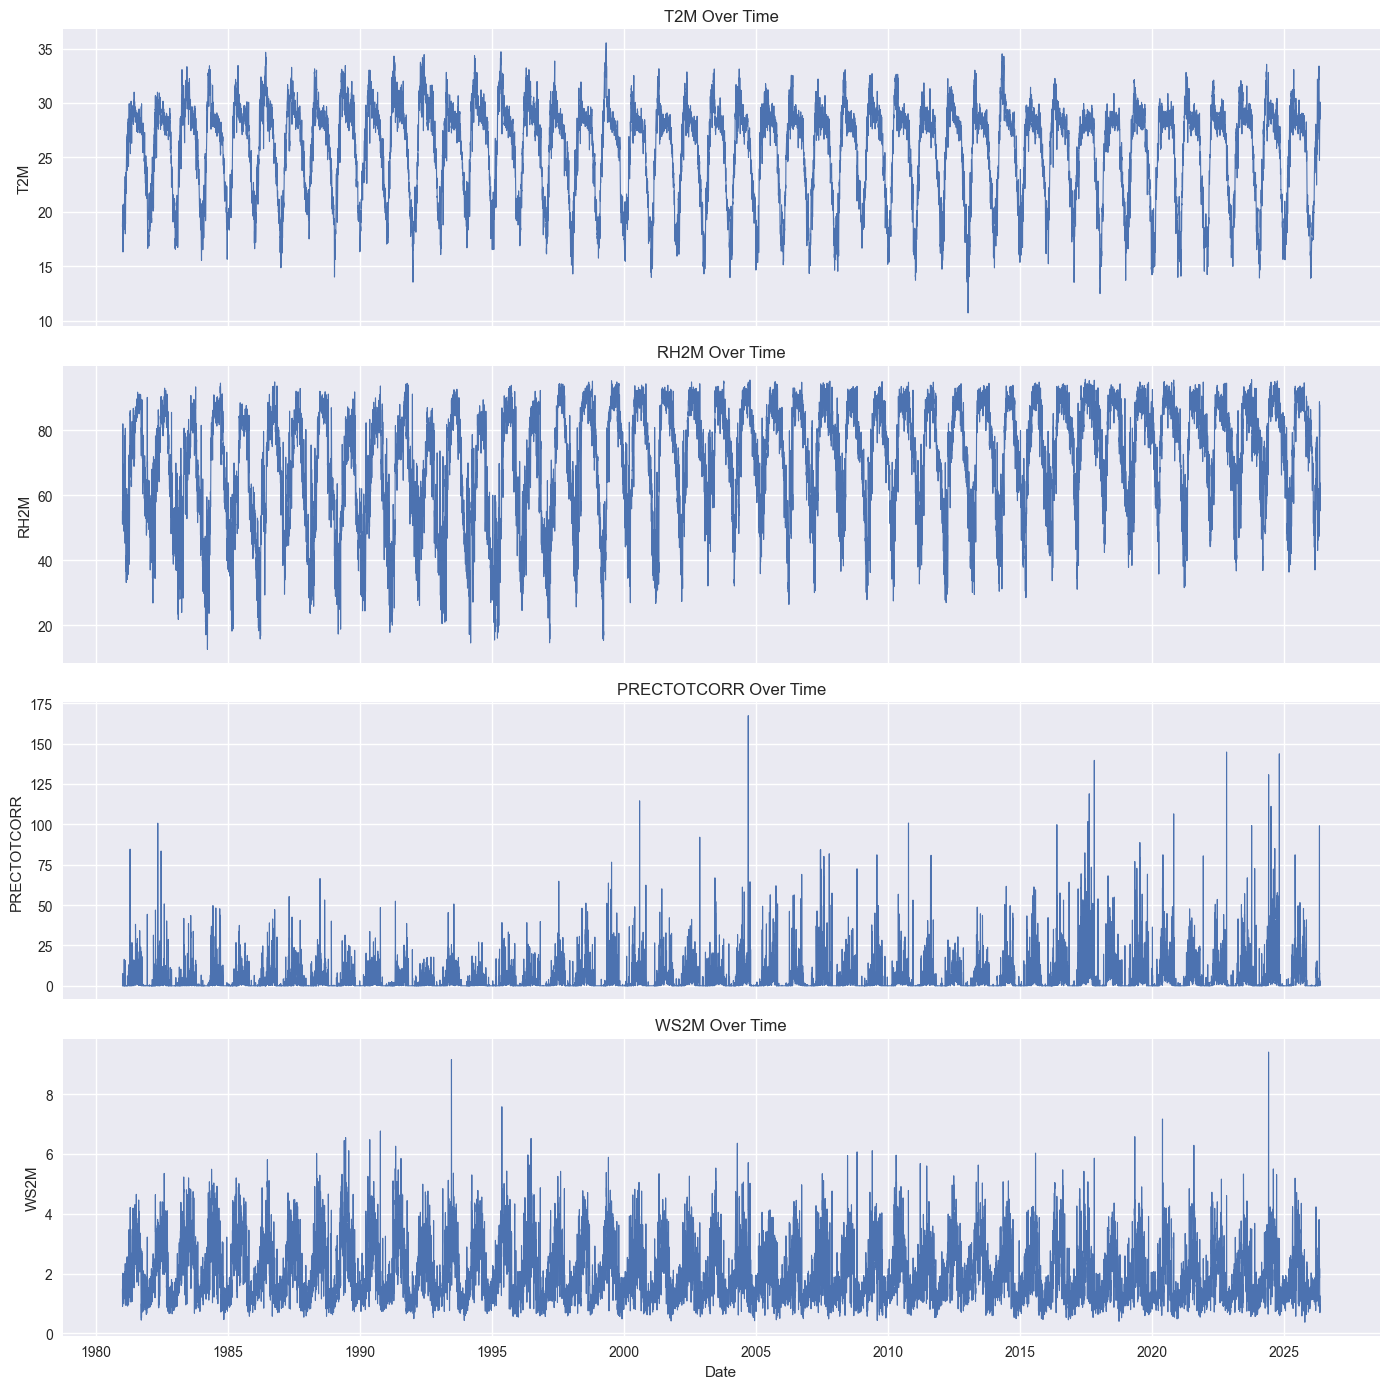

In [5]:
# Sort by date for clean time-series plotting
df = df.sort_values('DATE').reset_index(drop=True)

weather_vars = ['T2M', 'RH2M', 'PRECTOTCORR', 'WS2M']

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
for i, col in enumerate(weather_vars):
    axes[i].plot(df['DATE'], df[col], linewidth=0.8)
    axes[i].set_title(f'{col} Over Time')
    axes[i].set_ylabel(col)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

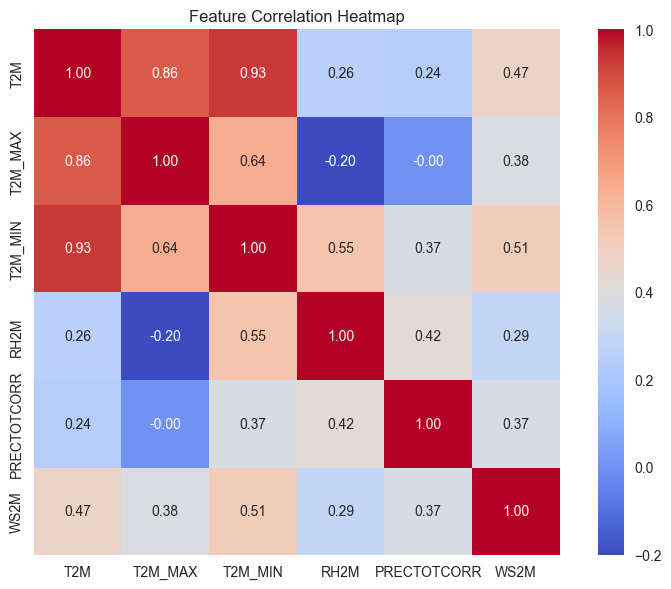

In [6]:
# Correlation heatmap
corr_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'PRECTOTCORR', 'WS2M']

plt.figure(figsize=(8, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

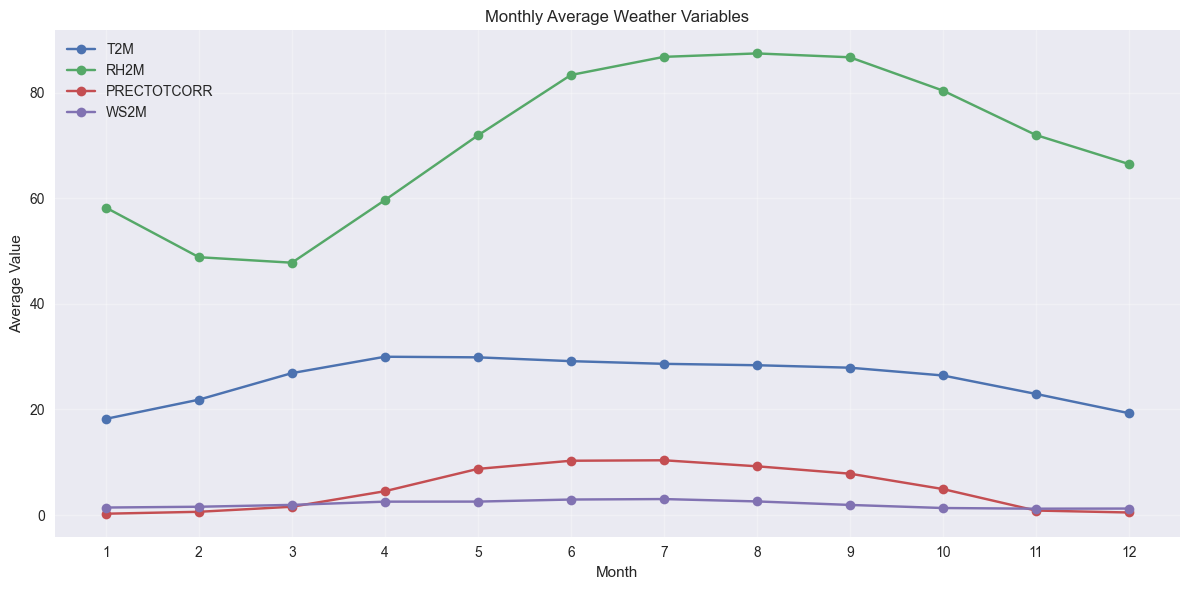

,T2M,RH2M,PRECTOTCORR,WS2M
MONTH,,,,
1,18.228401,58.226739,0.266122,1.435470
2,21.863657,48.839507,0.629145,1.585420
3,26.890351,47.796809,1.584516,1.936627
4,29.991275,59.653109,4.529435,2.548855
5,29.876598,71.900904,8.755438,2.559502
6,29.155378,83.343644,10.296667,2.951289
7,28.646875,86.778079,10.385799,3.039642
8,28.383061,87.427441,9.246939,2.591032
9,27.914822,86.698896,7.847096,1.928830


In [7]:
# Monthly averages
df['MONTH'] = df['DATE'].dt.month
monthly_avg = df.groupby('MONTH')[['T2M', 'RH2M', 'PRECTOTCORR', 'WS2M']].mean()

monthly_avg.plot(kind='line', marker='o', figsize=(12, 6))
plt.title('Monthly Average Weather Variables')
plt.xlabel('Month')
plt.ylabel('Average Value')
plt.xticks(range(1, 13))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

monthly_avg

## Step 3: Feature Engineering

In [8]:
# Drop YEAR, MO, DY columns
model_df = df.drop(columns=['YEAR', 'MO', 'DY']).copy()

# Fill NaN with column mean (numeric columns only)
numeric_cols = model_df.select_dtypes(include=[np.number]).columns
model_df[numeric_cols] = model_df[numeric_cols].fillna(model_df[numeric_cols].mean())

# Create target variable: next day's T2M
model_df['TARGET_T2M_NEXT_DAY'] = model_df['T2M'].shift(-1)

# Drop last row with NaN target
model_df = model_df.dropna(subset=['TARGET_T2M_NEXT_DAY']).reset_index(drop=True)

# Feature selection
feature_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'PRECTOTCORR', 'WS2M']
X = model_df[feature_cols].values
y = model_df['TARGET_T2M_NEXT_DAY'].values

# Normalize features to [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X)

# Train-test split (80/20), preserving time order
split_idx = int(len(X_scaled) * 0.8)
X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

print(f'X_train shape: {X_train_t.shape}')
print(f'X_test shape:  {X_test_t.shape}')
print(f'y_train shape: {y_train_t.shape}')
print(f'y_test shape:  {y_test_t.shape}')

X_train shape: torch.Size([13255, 6])
X_test shape:  torch.Size([3314, 6])
y_train shape: torch.Size([13255])
y_test shape:  torch.Size([3314])


## Step 4: QML Model (PennyLane + PyTorch Hybrid)

In [9]:
import pennylane as qml
import torch.nn as nn

# Qubit কমিয়ে 4 করলাম, layer 2
n_qubits = 4
n_layers = 2
dev = qml.device('lightning.qubit', wires=n_qubits)

@qml.qnode(dev, interface='torch')
def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs[:n_qubits], wires=range(n_qubits))
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

weight_shapes = {'weights': (n_layers, n_qubits, 3)}
quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

class HybridQMLModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.quantum = quantum_layer
        self.fc = nn.Linear(n_qubits, 1)

    def forward(self, x):
        q_out = self.quantum(x)
        out = self.fc(q_out)
        return out

model = HybridQMLModel()
print(model)
print("✅ Smaller circuit ready!")

HybridQMLModel(
  (quantum): <Quantum Torch Layer: func=quantum_circuit>
  (fc): Linear(in_features=4, out_features=1, bias=True)
)
✅ Smaller circuit ready!


## Step 5: Training

Subset size: torch.Size([500, 6])


Training:  20%|███▏            | 10/50 [05:48<23:15, 34.90s/it, Loss=367.336226]

Epoch [10/50], Loss: 367.336226


Training:  40%|██████▍         | 20/50 [11:29<17:14, 34.47s/it, Loss=113.377092]

Epoch [20/50], Loss: 113.377092


...

Epoch [30/50], Loss: 39.336122


Training:  80%|█████████████▌   | 40/50 [23:25<05:41, 34.18s/it, Loss=15.232408]

Epoch [40/50], Loss: 15.232408


Training: 100%|██████████████████| 50/50 [29:04<00:00, 34.90s/it, Loss=7.696354]

Epoch [50/50], Loss: 7.696354


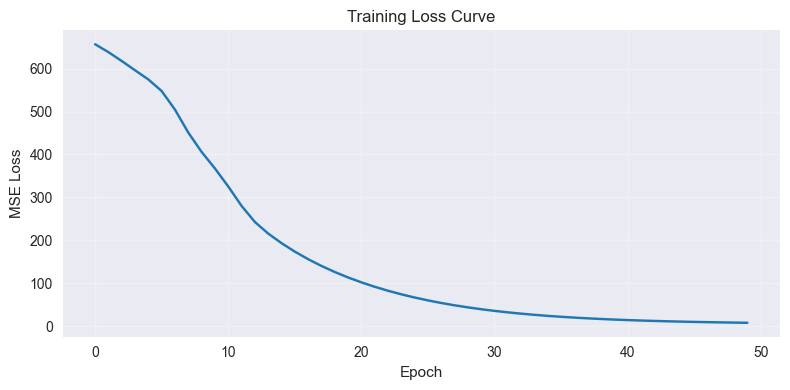

In [10]:
from tqdm import tqdm
from torch.utils.data import DataLoader, TensorDataset

# মাত্র 500 rows
subset_size = 500
X_train_sub = X_train_t[:subset_size]
y_train_sub = y_train_t[:subset_size]
print(f"Subset size: {X_train_sub.shape}")

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
epochs = 50  # 100 → 50
batch_size = 32
train_losses = []

dataset = TensorDataset(X_train_sub, y_train_sub)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

pbar = tqdm(range(1, epochs + 1), desc="Training", ncols=80)

for epoch in pbar:
    model.train()
    epoch_loss = 0.0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        preds = model(X_batch).squeeze()
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(loader)
    train_losses.append(avg_loss)
    pbar.set_postfix({'Loss': f'{avg_loss:.6f}'})
    
    if epoch % 10 == 0:
        tqdm.write(f'Epoch [{epoch}/{epochs}], Loss: {avg_loss:.6f}')

plt.figure(figsize=(8, 4))
plt.plot(train_losses, color='tab:blue')
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 6: Evaluation

MAE:  2.7629
RMSE: 3.0933
R2:   0.5166


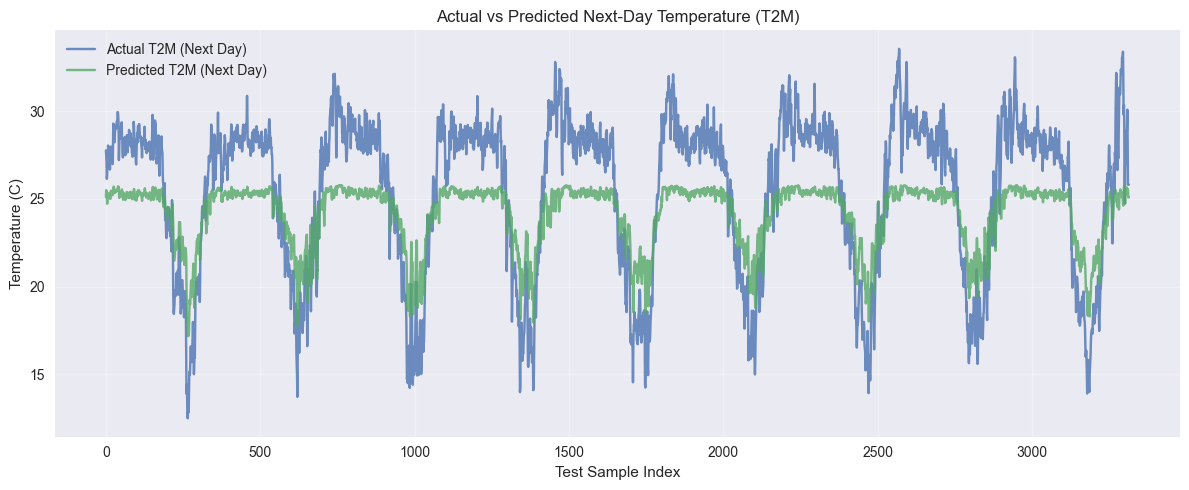

In [11]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test_t).squeeze().numpy()

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'MAE:  {mae:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'R2:   {r2:.4f}')

# Plot actual vs predicted
plt.figure(figsize=(12, 5))
plt.plot(y_test, label='Actual T2M (Next Day)', alpha=0.8)
plt.plot(y_pred, label='Predicted T2M (Next Day)', alpha=0.8)
plt.title('Actual vs Predicted Next-Day Temperature (T2M)')
plt.xlabel('Test Sample Index')
plt.ylabel('Temperature (C)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 7: Save Model & Scaler

In [12]:
# Save trained model
model_path = r"D:\\Quantum-Enhanced Weather Forecasting for Bangladesh\\quantweather_bd_model.pth"
torch.save(model.state_dict(), model_path)

# Save scaler
scaler_path = r"D:\\Quantum-Enhanced Weather Forecasting for Bangladesh\\scaler.pkl"
joblib.dump(scaler, scaler_path)

print(f'Model saved to: {model_path}')
print(f'Scaler saved to: {scaler_path}')

Model saved to: D:\\Quantum-Enhanced Weather Forecasting for Bangladesh\\quantweather_bd_model.pth
Scaler saved to: D:\\Quantum-Enhanced Weather Forecasting for Bangladesh\\scaler.pkl
